# Lecture 5 companion 2 · EWMA and momentum

Momentum starts with a small idea: **remember a useful direction instead of trusting only the newest measurement**.

We will build that idea in five concrete steps:

1. smooth the same noisy temperature signal with short, medium, and long memory;
2. derive an actual ravine from four regression examples;
3. ask whether feature standardization fixes that ravine;
4. work two momentum updates by hand; and
5. test plain GD and momentum on the exact same loss and gradient budget.

The final cell checks our recurrence against PyTorch's real `momentum_buffer`. No decorative loss surface is used: every optimizer path comes from the displayed four-row dataset.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INK = '#23373B'
MUTED = '#6E7F82'
BLUE = '#2B6CB0'
TEAL = '#2C7A7B'
ORANGE = '#EB811B'
PURPLE = '#7952A8'
RED = '#D64550'

np.set_printoptions(precision=7, suppress=True)
plt.rcParams.update({
    'figure.dpi': 125,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': .18,
    'font.size': 10.5,
    'legend.frameon': False,
})

## 1. Start with noisy observations—not the formula

The grey dots below are a deterministic, constructed 120-day temperature sequence. A slow seasonal pattern is present, but one day's reading can jump because of noise.

Our question is deliberately simple: **how can we carry one running estimate of the changing trend without storing and re-averaging every past reading?**

Use the companion [EWMA + momentum explorer](https://nipunbatra.github.io/dl-teaching/interactives/ewma-explorer.html) to move through the same observations one day at a time, vary $\beta$, and then inspect the optimizer memory on the computed ravine.

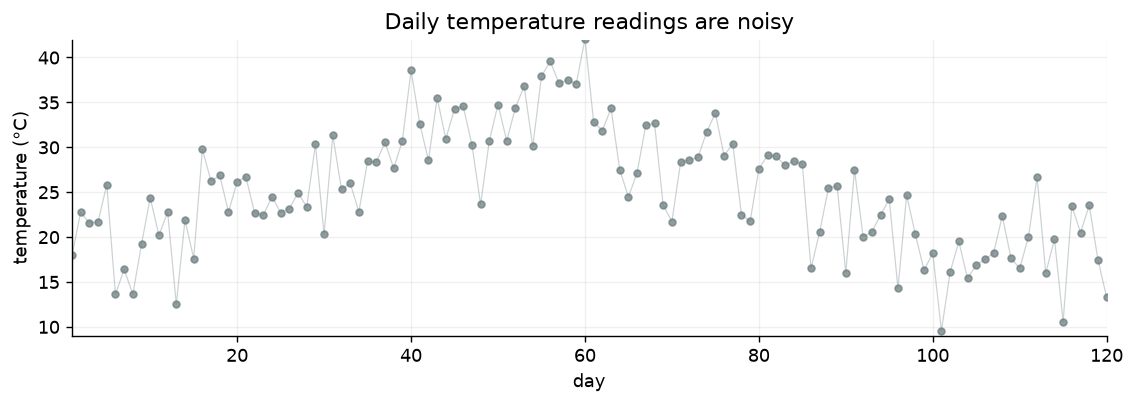

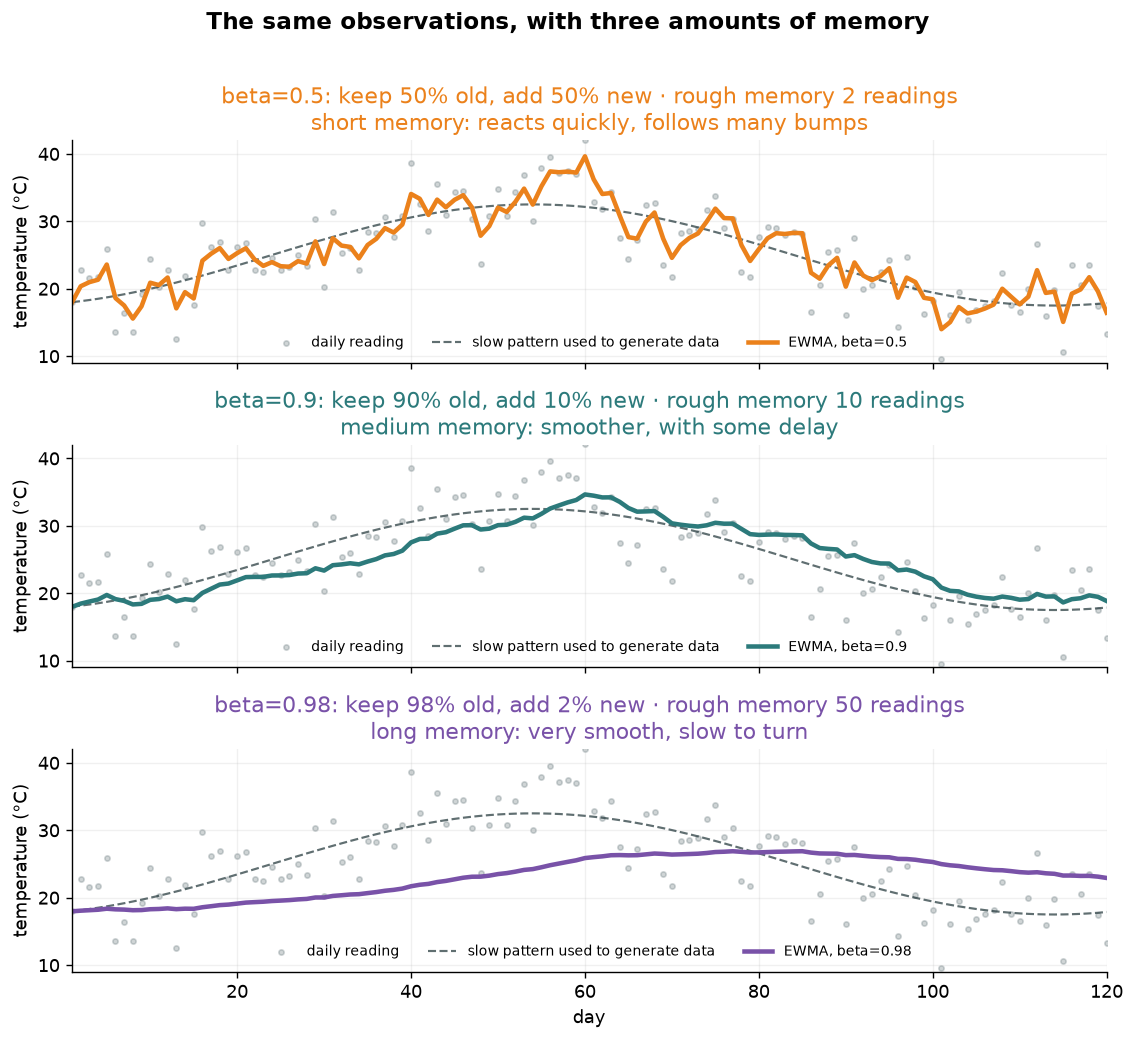

 beta | keep old | add new | rough memory | visible trade-off
 0.50 |     0.50 |    0.50 |            2 | short memory: reacts quickly, follows many bumps
 0.90 |     0.90 |    0.10 |           10 | medium memory: smoother, with some delay
 0.98 |     0.98 |    0.02 |           50 | long memory: very smooth, slow to turn


In [2]:
day = np.arange(1, 121)
temperature_trend = 25.0 + 7.5 * np.sin(2 * np.pi * (day - 24) / 120)
rng = np.random.default_rng(12)
temperature = temperature_trend + rng.normal(0.0, 4.4, size=len(day))

def ewma_from_first(values, beta):
    """Start at the first reading so this plot isolates smoothing and lag."""
    state = float(values[0])
    smoothed = [state]
    for value in values[1:]:
        state = beta * state + (1 - beta) * value
        smoothed.append(state)
    return np.asarray(smoothed)

assert np.allclose(
    temperature[:3],
    [17.96810897, 22.75143955, 21.58044012],
)

fig, ax = plt.subplots(figsize=(9.2, 3.35))
ax.scatter(day, temperature, s=15, color=MUTED, alpha=.75)
ax.plot(day, temperature, color=MUTED, lw=.7, alpha=.35)
ax.set(
    xlim=(1, 120), ylim=(9, 42), xlabel='day', ylabel='temperature (°C)',
    title='Daily temperature readings are noisy',
)
plt.tight_layout()
plt.show()

beta_specs = [
    (.50, ORANGE, 'short memory: reacts quickly, follows many bumps'),
    (.90, TEAL, 'medium memory: smoother, with some delay'),
    (.98, PURPLE, 'long memory: very smooth, slow to turn'),
]
fig, axes = plt.subplots(3, 1, figsize=(9.2, 8.2), sharex=True, sharey=True)
for ax, (beta, color, interpretation) in zip(axes, beta_specs):
    smoothed = ewma_from_first(temperature, beta)
    ax.scatter(day, temperature, s=9, color=MUTED, alpha=.32, label='daily reading')
    ax.plot(day, temperature_trend, '--', color=INK, lw=1.25,
            alpha=.72, label='slow pattern used to generate data')
    ax.plot(day, smoothed, color=color, lw=2.6,
            label=f'EWMA, beta={beta:g}')
    rough_memory = int(round(1 / (1 - beta)))
    ax.set_title(
        f'beta={beta:g}: keep {100*beta:.0f}% old, add {100*(1-beta):.0f}% new · '
        f'rough memory {rough_memory} readings\n{interpretation}',
        color=color,
    )
    ax.set_ylabel('temperature (°C)')
    ax.legend(ncol=3, fontsize=8.2, loc='lower center')
axes[-1].set_xlabel('day')
axes[0].set_xlim(1, 120)
axes[0].set_ylim(9, 42)
fig.suptitle('The same observations, with three amounts of memory', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' beta | keep old | add new | rough memory | visible trade-off')
for beta, _, interpretation in beta_specs:
    print(f' {beta:>4.2f} | {beta:>8.2f} | {1-beta:>7.2f} | '
          f'{1/(1-beta):>12.0f} | {interpretation}')

### EWMA keeps one running memory $m_t$

Here $m_t$ is the **running memory**: the smoothed value after processing observation $x_t$. Keep a fraction $\beta$ of the previous memory and admit a fraction $1-\beta$ of today's observation:

$$m_t=\beta m_{t-1}+(1-\beta)x_t,\qquad 0\leq\beta<1.$$

- The two weights in each recurrence sum to one, so the summary stays on the same scale as the readings.
- Small $\beta$ reacts quickly; large $\beta$ smooths more but lags when the signal turns.
- $1/(1-\beta)$ is a useful rough timescale, not a hard window.
- The displayed temperature curves use the warm start $m_1=x_1$, so they do not begin by shrinking toward zero.

One worked update uses the same convention as the lecture:

$$m_{t-1}=30,\quad x_t=36,\quad\beta=.9
\quad\Longrightarrow\quad
m_t=.9(30)+.1(36)=30.6.$$

### Why ‘exponential’? Unroll the memory

Substitute the same recurrence for the previous memory $m_{t-1}$:

$$\begin{aligned}
m_t
&=\beta[\beta m_{t-2}+(1-\beta)x_{t-1}]+(1-\beta)x_t\\
&=(1-\beta)x_t+(1-\beta)\beta x_{t-1}+\beta^2m_{t-2}.
\end{aligned}$$

Substituting once more gives

$$m_t=(1-\beta)x_t+(1-\beta)\beta x_{t-1}
+(1-\beta)\beta^2x_{t-2}+\beta^3m_{t-3}.$$

For a **zero-start** recurrence, the weight on $x_{t-k}$ is $(1-\beta)\beta^k$: every step into the past contributes one more factor of $\beta$. With the warm start used in the temperature plots, the oldest reading $x_1$ instead carries the remaining weight $\beta^{t-1}$, so all displayed weights sum to one from the first day. For $\beta=.9$, the recent-observation weights are

$$.100,\quad .090,\quad .081,\quad .0729,\quad\ldots$$

The weights decay geometrically—by powers of $\beta$. That is the *exponential* in EWMA.

### What changes if the running memory starts at zero?

The temperature curves above used $m_1=x_1$. Optimizer memories instead commonly begin at zero, so use the **same fixed-seed temperature readings** to expose the resulting cold start. With $m_0=0$ and $\beta=.9$,

$$m_1=.9(0)+.1x_1=.1(17.968)=1.797.$$

That is not a sensible average of the observed temperatures: only $.1$ total data weight has arrived. After day $t$, the arrived mass is

$$w_t=(1-\beta)\sum_{k=0}^{t-1}\beta^k=1-\beta^t,$$

so $\widehat m_t=m_t/w_t$ is a normalized weighted average of the observations seen so far. This correction removes the known pull from the chosen initial zero; it does **not** remove measurement noise. Warm-starting and correcting a zero start agree on day 1, but they are not identical early trajectories.


day | reading | raw zero start | arrived mass | corrected | warm start
  1 |  17.968 |          1.797 |        0.100 |    17.968 |     17.968
  2 |  22.751 |          3.892 |        0.190 |    20.486 |     18.446
  3 |  21.580 |          5.661 |        0.271 |    20.890 |     18.760


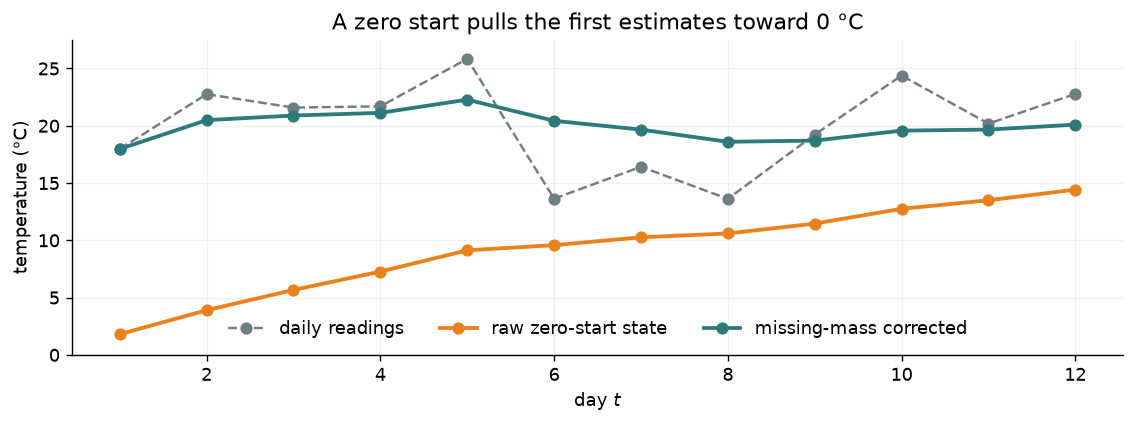

In [3]:
beta = 0.9
first_days = temperature[:12]
raw_zero_start = []
corrected_zero_start = []
state = 0.0
for t, value in enumerate(first_days, start=1):
    state = beta * state + (1 - beta) * value
    raw_zero_start.append(state)
    corrected_zero_start.append(state / (1 - beta**t))
raw_zero_start = np.asarray(raw_zero_start)
corrected_zero_start = np.asarray(corrected_zero_start)
warm_start = ewma_from_first(first_days, beta)

print('day | reading | raw zero start | arrived mass | corrected | warm start')
for t in range(3):
    print(f'{t+1:>3} | {first_days[t]:>7.3f} | {raw_zero_start[t]:>14.3f} | '
          f'{1-beta**(t+1):>12.3f} | {corrected_zero_start[t]:>9.3f} | '
          f'{warm_start[t]:>10.3f}')

fig, ax = plt.subplots(figsize=(9.2, 3.5))
days = np.arange(1, len(first_days) + 1)
ax.plot(days, first_days, 'o--', color=MUTED, lw=1.4, label='daily readings')
ax.plot(days, raw_zero_start, 'o-', color=ORANGE, lw=2.2, label='raw zero-start state')
ax.plot(days, corrected_zero_start, 'o-', color=TEAL, lw=2.2,
        label='missing-mass corrected')
ax.set(xlabel='day $t$', ylabel='temperature (°C)', ylim=(0, 27.5),
       title='A zero start pulls the first estimates toward 0 °C')
ax.legend(ncol=3, loc='lower center')
plt.tight_layout()
plt.show()

assert np.allclose(raw_zero_start[:3], [1.796810897, 3.892273762, 5.661090398])
assert np.allclose(corrected_zero_start[:3], [17.96810897, 20.48565138, 20.88963247])


In [4]:
previous_summary = 30.0
today = 36.0
beta = 0.9
updated_summary = beta * previous_summary + (1 - beta) * today

print(f'keep old: {beta:.1f} × {previous_summary:.1f} = {beta*previous_summary:.1f}')
print(f'add new:  {1-beta:.1f} × {today:.1f} = {(1-beta)*today:.1f}')
print(f'updated summary = {updated_summary:.1f} °C')
assert np.isclose(updated_summary, 30.6)

keep old: 0.9 × 30.0 = 27.0
add new:  0.1 × 36.0 = 3.6
updated summary = 30.6 °C


## 2. Derive the ravine from four regression examples

Now return to optimization. Use

$$\hat y_i=\theta_1x_{i1}+\theta_2x_{i2},\qquad
  \boldsymbol\theta^*=(1,-0.5),$$

and generate the targets from the known parameter:

| row $i$ | $x_{i1}$ | $x_{i2}$ | $y_i$ |
|---:|---:|---:|---:|
| 1 | -1 | -10 | 4 |
| 2 | -1 | 10 | -6 |
| 3 | 1 | -10 | 6 |
| 4 | 1 | 10 | -4 |

Start at the actual parameter value $\boldsymbol\theta_0=(-1.4,.35)$. Because $\boldsymbol y=\boldsymbol X\boldsymbol\theta^*$, the residuals are $\boldsymbol X(\boldsymbol\theta-\boldsymbol\theta^*)$. The balanced signs cancel the cross terms, while the second feature's factor of 10 is squared:

$$\frac{\boldsymbol X^\top\boldsymbol X}{N}
  =\begin{bmatrix}1&0\\0&100\end{bmatrix},$$

$$\mathcal L(\boldsymbol\theta)
  =\frac{1}{2N}\|\boldsymbol X\boldsymbol\theta-\boldsymbol y\|^2
  =\frac12(\theta_1-1)^2+50(\theta_2+0.5)^2,$$

$$\nabla\mathcal L(\boldsymbol\theta)
  =(\theta_1-1,\;100(\theta_2+0.5)).$$

This is a computed empirical loss: the ravine comes from the four displayed rows, and the optimum is visibly $\boldsymbol\theta^*=(1,-.5)$.

In [5]:
X = np.array([[-1., -10.], [-1., 10.], [1., -10.], [1., 10.]])
theta_star = np.array([1., -0.5])
y = X @ theta_star
theta0 = np.array([-1.4, 0.35])

def loss_theta(theta):
    return 0.5 * np.mean((X @ theta - y) ** 2)

def grad_theta(theta):
    residual = X @ theta - y
    return X.T @ residual / len(X)

H = X.T @ X / len(X)
prediction0 = X @ theta0
residual0 = prediction0 - y

print(f"{'row':>3} {'x1':>5} {'x2':>5} {'y':>7} {'yhat':>8} {'residual':>10}")
for i, (row, target, pred, residual) in enumerate(
    zip(X, y, prediction0, residual0), start=1
):
    print(f'{i:>3} {row[0]:>5.0f} {row[1]:>5.0f} {target:>7.1f} '
          f'{pred:>8.1f} {residual:>10.1f}')

print('\nX^T X / N =\n', H)
print('theta* =', theta_star)
print('theta0 =', theta0)
print('full gradient at theta0 =', grad_theta(theta0))
print(f'full loss at theta0 = {loss_theta(theta0):.3f}')

assert np.allclose(H, np.diag([1., 100.]))
assert np.allclose(residual0, X @ (theta0 - theta_star))
assert np.allclose(grad_theta(theta0), [-2.4, 85.])
assert np.isclose(loss_theta(theta0), 39.005)

row    x1    x2       y     yhat   residual
  1    -1   -10     4.0     -2.1       -6.1
  2    -1    10    -6.0      4.9       10.9
  3     1   -10     6.0     -4.9      -10.9
  4     1    10    -4.0      2.1        6.1

X^T X / N =
 [[  1.   0.]
 [  0. 100.]]
theta* = [ 1.  -0.5]
theta0 = [-1.4   0.35]
full gradient at theta0 = [-2.4 85. ]
full loss at theta0 = 39.005


### See the ravine as a 3-D loss surface

The horizontal plane contains the model parameters; height is the exact full-batch loss. The surface is shallow **along** $\theta_1$ and steep **across** $\theta_2$, so its low-loss floor is long and narrow.

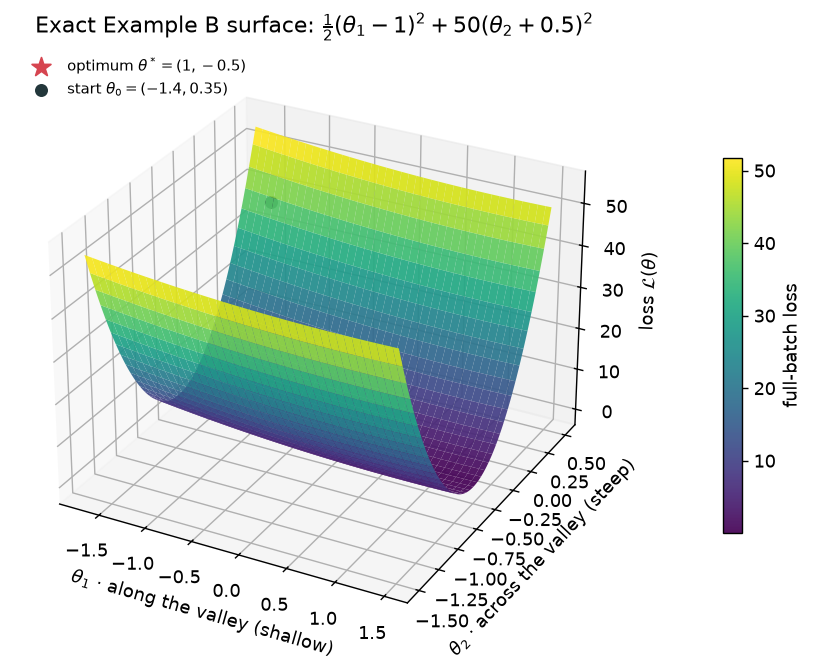

In [6]:
theta1_surface = np.linspace(-1.7, 1.5, 160)
theta2_surface = np.linspace(-1.5, 0.5, 160)
T1_surface, T2_surface = np.meshgrid(theta1_surface, theta2_surface)
L_surface = 0.5 * (T1_surface - 1)**2 + 50 * (T2_surface + 0.5)**2

fig = plt.figure(figsize=(8.8, 5.4))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(
    T1_surface, T2_surface, L_surface,
    cmap='viridis', alpha=.92, linewidth=0, antialiased=True,
)
ax.scatter(*theta_star, 0, marker='*', s=130, color=RED,
           label=r'optimum $\theta^*=(1,-0.5)$')
ax.scatter(*theta0, loss_theta(theta0), s=42, color=INK,
           label=r'start $\theta_0=(-1.4,0.35)$')
ax.set(
    xlabel=r'$\theta_1$ · along the valley (shallow)',
    ylabel=r'$\theta_2$ · across the valley (steep)',
    zlabel=r'loss $\mathcal{L}(\theta)$',
    title=r'Exact Example B surface: $\frac{1}{2}(\theta_1-1)^2+50(\theta_2+0.5)^2$',
)
ax.view_init(elev=28, azim=-62)
ax.legend(loc='upper left', fontsize=8.5)
fig.colorbar(surface, ax=ax, shrink=.62, pad=.10, label='full-batch loss')
plt.tight_layout()
plt.show()

check_points = np.array([theta_star, theta0, [0., 0.]])
closed_form = 0.5 * (check_points[:, 0] - 1)**2 + 50 * (check_points[:, 1] + 0.5)**2
assert np.allclose([loss_theta(theta) for theta in check_points], closed_form)

### One learning rate must serve two very different coordinates

Plain GD changes the two distances from the optimum independently:

$$\theta_{t+1,1}-1=(1-\eta)(\theta_{t,1}-1),$$

$$\theta_{t+1,2}+0.5=(1-100\eta)(\theta_{t,2}+0.5).$$

The multiplier's **sign** says whether the path crosses the minimum; its **magnitude** says how much distance remains.

| $\eta$ | shallow multiplier | steep multiplier | outcome |
|---:|---:|---:|:---|
| .005 | .995 | .5 | stable, but slow along the valley |
| .0195 | .9805 | -.95 | stable, slowly contracting zigzag |
| .021 | .979 | -1.1 | expanding zigzag |

At $\eta=.0195$, the exact first gradient is $(-2.4,85)$ and the first update in the original parameter space is

$$\boldsymbol\theta_1=(-1.4,.35)-.0195(-2.4,85)=(-1.3532,-1.3075).$$

The gradient is exact. The difficulty is that one global learning rate must be small enough for the steep direction, so progress along the shallow direction is slow.

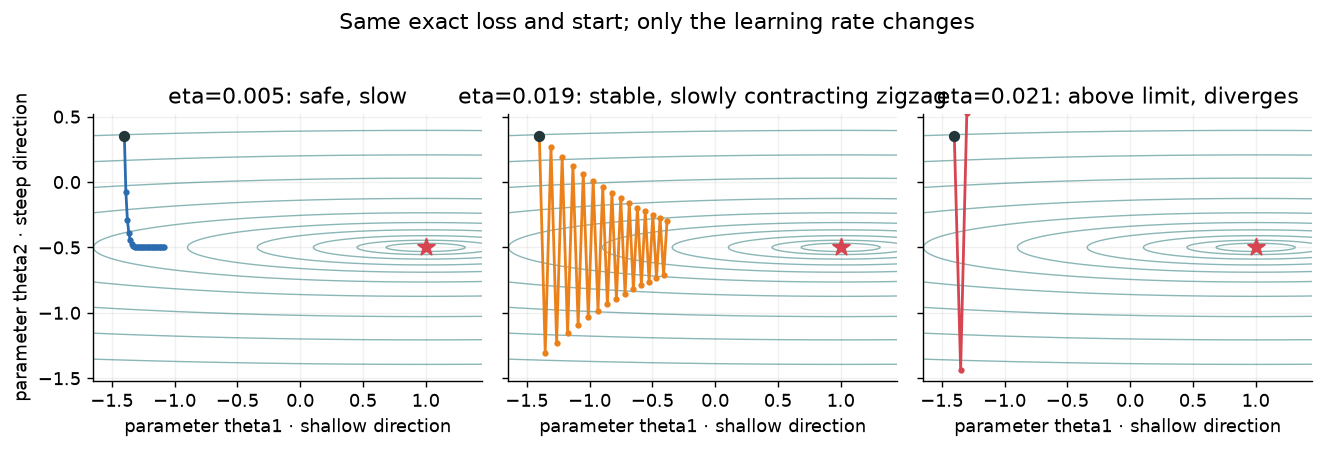

eta=0.005 | steep multiplier= 0.50 | loss after 28 updates=2.1751 | safe, slow
eta=0.019 | steep multiplier=-0.95 | loss after 28 updates=2.9993 | stable, slowly contracting zigzag
eta=0.021 | steep multiplier=-1.10 | loss after 12 updates=357.5521 | above limit, diverges


In [7]:
def gd_path(eta, steps):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - eta * grad_theta(theta)
        path.append(theta.copy())
    return np.asarray(path)

theta1_grid = np.linspace(-1.65, 1.45, 260)
theta2_grid = np.linspace(-1.52, .52, 260)
THETA1, THETA2 = np.meshgrid(theta1_grid, theta2_grid)
loss_grid = 0.5 * (THETA1 - theta_star[0])**2 + 50 * (THETA2 - theta_star[1])**2
contour_levels = [.05, .15, .4, .9, 1.8, 3.5, 7, 14, 25, 40]

rate_specs = [
    (.005, 28, 'safe, slow', BLUE),
    (.0195, 28, 'stable, slowly contracting zigzag', ORANGE),
    (.021, 12, 'above limit, diverges', RED),
]
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.45), sharex=True, sharey=True)
for ax, (eta, steps, description, color) in zip(axes, rate_specs):
    path = gd_path(eta, steps)
    ax.contour(THETA1, THETA2, loss_grid, levels=contour_levels,
               colors=TEAL, alpha=.55, linewidths=.8)
    visible = np.abs(path[:, 1] - theta_star[1]) <= 1.03
    stop = np.flatnonzero(~visible)
    stop = stop[0] if len(stop) else len(path)
    ax.plot(path[:stop, 0], path[:stop, 1], 'o-', color=color, ms=2.6, lw=1.6)
    ax.scatter(*theta0, color=INK, s=30, zorder=5)
    ax.scatter(*theta_star, marker='*', s=105, color=RED, zorder=5)
    ax.set(
        title=f'eta={eta:.3f}: {description}', xlabel='parameter theta1 · shallow direction',
        xlim=(-1.65, 1.45), ylim=(-1.52, .52),
    )
axes[0].set_ylabel('parameter theta2 · steep direction')
fig.suptitle('Same exact loss and start; only the learning rate changes', y=1.03)
plt.tight_layout()
plt.show()

for eta, steps, description, _ in rate_specs:
    path = gd_path(eta, steps)
    multiplier = 1 - 100 * eta
    print(f'eta={eta:.3f} | steep multiplier={multiplier:>5.2f} | '
          f'loss after {steps:>2} updates={loss_theta(path[-1]):.4f} | {description}')

assert loss_theta(gd_path(.005, 28)[-1]) < loss_theta(theta0)
assert loss_theta(gd_path(.0195, 28)[-1]) < loss_theta(theta0)
assert loss_theta(gd_path(.021, 12)[-1]) > loss_theta(theta0)

## 3. Could feature standardization fix this example?

**Yes—for this particular constructed problem.** Define $z_2=x_2/10$. To keep every prediction unchanged, transform the corresponding coefficient as $\phi_2=10\theta_2$:

$$\theta_2x_2=\phi_2z_2.$$

The standardized model's actual parameter vector is

$$\boldsymbol\phi=(\theta_1,10\theta_2),\qquad
  \boldsymbol\phi_0=(-1.4,3.5),\qquad
  \boldsymbol\phi^*=(1,-5).$$

Then

$$\frac{\boldsymbol Z^\top\boldsymbol Z}{N}=I,\qquad
  \mathcal L(\boldsymbol\phi)=\frac12(\phi_1-1)^2+\frac12(\phi_2+5)^2.$$

The two directions now have the same curvature, so plain GD can take one reasonably large step size in both.

raw curvature matrix:
 [[  1.   0.]
 [  0. 100.]]
after z2=x2/10:
 [[1. 0.]
 [0. 1.]]
phi0 = [-1.4  3.5] | phi* = [ 1. -5.]
same initial full loss: raw=39.005, standardized=39.005
after 10 updates: raw=14.892730, standardized=0.007069


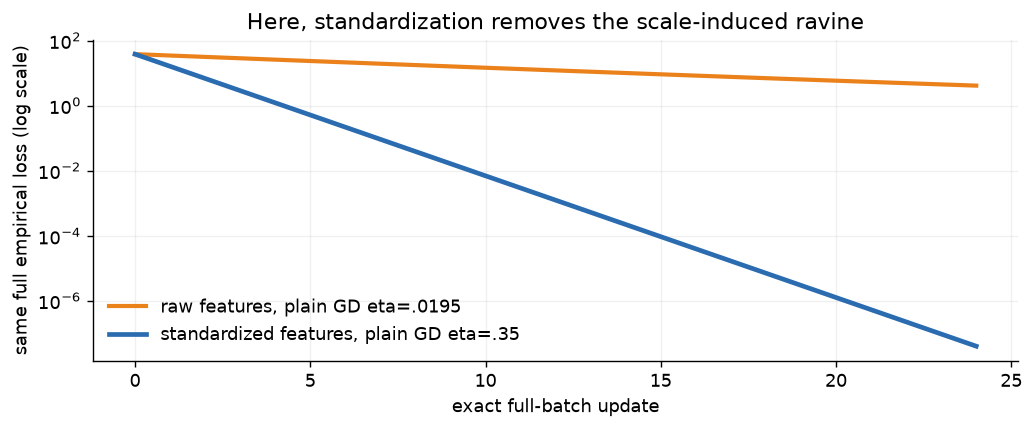

In [8]:
Z = X / np.array([1.0, 10.0])
H_standardized = Z.T @ Z / len(Z)
phi0 = np.array([theta0[0], 10 * theta0[1]])
phi_star = np.array([theta_star[0], 10 * theta_star[1]])

def loss_phi(phi):
    return 0.5 * np.mean((Z @ phi - y) ** 2)

def standardized_gd_path(eta, steps):
    phi = phi0.copy()
    path = [phi.copy()]
    for _ in range(steps):
        phi = phi - eta * (Z.T @ (Z @ phi - y) / len(Z))
        path.append(phi.copy())
    return np.asarray(path)

raw_path = gd_path(.0195, 24)
standardized_path = standardized_gd_path(.35, 24)
raw_losses = np.array([loss_theta(theta) for theta in raw_path])
standardized_losses = np.array([loss_phi(phi) for phi in standardized_path])

print('raw curvature matrix:\n', H)
print('after z2=x2/10:\n', H_standardized)
print('phi0 =', phi0, '| phi* =', phi_star)
print(f'same initial full loss: raw={raw_losses[0]:.3f}, standardized={standardized_losses[0]:.3f}')
print(f'after 10 updates: raw={raw_losses[10]:.6f}, standardized={standardized_losses[10]:.6f}')

fig, ax = plt.subplots(figsize=(8.4, 3.55))
ax.semilogy(raw_losses, color=ORANGE, lw=2.4,
            label='raw features, plain GD eta=.0195')
ax.semilogy(standardized_losses, color=BLUE, lw=2.7,
            label='standardized features, plain GD eta=.35')
ax.set(
    xlabel='exact full-batch update', ylabel='same full empirical loss (log scale)',
    title='Here, standardization removes the scale-induced ravine',
)
ax.legend()
plt.tight_layout()
plt.show()

assert np.allclose(H_standardized, np.eye(2))
assert np.isclose(raw_losses[0], standardized_losses[0])
assert np.isclose(standardized_losses[10], 0.007069479103462469)
assert standardized_losses[10] < raw_losses[10]

### Does normalization make momentum obsolete? No.

- **Do first:** normalize input features when their scales differ strongly. It completely removes the $100{:}1$ imbalance in this deliberately scale-only example.
- **What remains:** deep networks create correlated, coupled, and changing directions in parameter space; input scaling cannot make all of that geometry uniformly round.
- **Minibatches still fluctuate:** normalization does not make every sampled gradient identical.

**Normalization changes the geometry. Momentum changes how successive gradients are combined. They are complementary.**

### Exact four-row example: standardized but correlated

Use the four training rows

| $i$ | $x_{i1}$ | $x_{i2}$ | $y_i$ |
|---:|---:|---:|---:|
| 1 | $-1$ | $-7/5$ | $-1$ |
| 2 | $-1$ | $-1/5$ | $-1$ |
| 3 | $1$ | $1/5$ | $1$ |
| 4 | $1$ | $7/5$ | $1$ |

The target is exactly $y=x_1$, so $\boldsymbol\theta^*=(1,0)$. Both feature means are zero. Their population variances are

$$\frac{1+1+1+1}{4}=1,\qquad
\frac{49+1+1+49}{4\cdot25}=1.$$

Because the columns are standardized, their correlation is their mean product:

$$\operatorname{corr}(x_1,x_2)=\frac{7/5+1/5+1/5+7/5}{4}=.8.$$

Thus

$$H=\frac{X^\top X}{4}=\begin{bmatrix}1&.8\\.8&1\end{bmatrix},$$

with eigenvalues $.2$ and $1.8$. Its condition number is $1.8/.2=9$, and equal-loss contours have long-to-short axis ratio $\sqrt9=3$. Standardization fixed the units, but correlation still leaves an elongated valley.

Use the same normalized EWMA recurrence as in the temperature example:

$$\boldsymbol m_{t+1}=\beta\boldsymbol m_t+(1-\beta)\boldsymbol g_t,\qquad
\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\boldsymbol m_{t+1},\qquad
\boldsymbol m_0=\boldsymbol0.$$

For a direct comparison, give plain GD and momentum the **same conceptual learning rate** $\eta=1$; momentum uses $\beta=.25$. Both computed loss curves below decrease at every update.

Before substituting numbers, note what the zero start does:

$$\boldsymbol m_1=(1-\beta)\boldsymbol g_0=.75\boldsymbol g_0,$$

$$\Delta\boldsymbol\theta_0^{\rm mom}=-1(.75\boldsymbol g_0)=-.75\boldsymbol g_0,\qquad
\Delta\boldsymbol\theta_0^{\rm GD}=-1\boldsymbol g_0=-\boldsymbol g_0.$$

At $\boldsymbol\theta_0=(-7/5,7/20)$, both methods measure $\boldsymbol g_0=(-53/25,-157/100)=(-2.12,-1.57)$. Momentum's first move is therefore $75\%$ of GD's first move because $\boldsymbol m_0=\boldsymbol0$; from update 2 onward, the memory also blends old and new gradients.

feature means: [0. 0.]
population variances: [1. 1.]
correlation: 0.8
H =
 [[1.  0.8]
 [0.8 1. ]]
eigenvalues: [0.2 1.8]
condition number: 9 | contour-axis ratio: 3
shared conceptual learning rate eta = 1.0
GD first displacement: [2.12 1.57]
momentum first displacement: [1.59   1.1775]
strictly decreasing losses: True True


#### First four computed updates · shared eta = 1

| update | GD $\theta_t$ | GD loss | normalized memory $m_t$ | momentum $\theta_t$ | momentum loss |
|---:|:---|---:|:---|:---|---:|
| 0 | `(-1.4000, 0.3500)` | `2.269250` | `—` | `(-1.4000, 0.3500)` | `2.269250` |
| 1 | `(0.7200, 1.9200)` | `1.452320` | `(-1.5900, -1.1775)` | `(0.1900, 1.5275)` | `0.504858` |
| 2 | `(-0.5360, 0.2240)` | `0.929485` | `(-0.0885, 0.3652)` | `(0.2785, 1.1623)` | `0.264843` |
| 3 | `(0.8208, 1.2288)` | `0.594870` | `(0.1341, 0.5301)` | `(0.1444, 0.6321)` | `0.133138` |
| 4 | `(0.0170, 0.1434)` | `0.380717` | `(-0.2289, 0.0933)` | `(0.3733, 0.5389)` | `0.071402` |

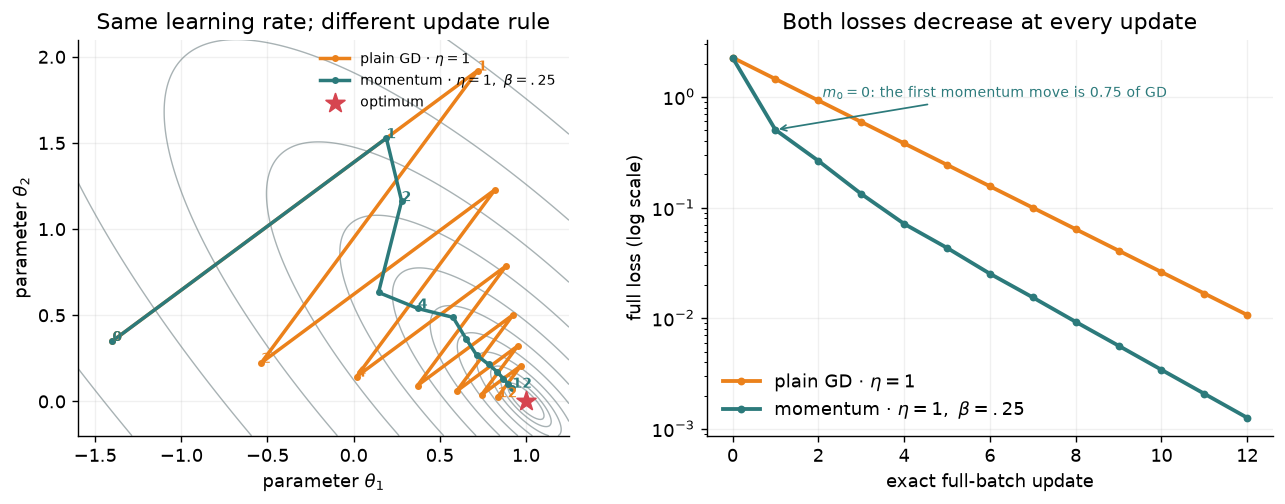

In [9]:
from IPython.display import Markdown, display

# Four exact rows: both columns have mean 0 and population variance 1.
corr_X = np.array([
    [-1.0, -7 / 5],
    [-1.0, -1 / 5],
    [ 1.0,  1 / 5],
    [ 1.0,  7 / 5],
])
corr_y = corr_X[:, 0].copy()  # y = x1
corr_n = len(corr_X)
corr_theta_star = np.array([1.0, 0.0])
corr_theta0 = np.array([-7 / 5, 7 / 20])
corr_H = corr_X.T @ corr_X / corr_n
corr_eigenvalues = np.linalg.eigvalsh(corr_H)
corr_condition = corr_eigenvalues[-1] / corr_eigenvalues[0]
corr_axis_ratio = np.sqrt(corr_condition)


def corr_loss(theta):
    residual = corr_X @ theta - corr_y
    return 0.5 * np.mean(residual**2)


def corr_gradient(theta):
    residual = corr_X @ theta - corr_y
    return corr_X.T @ residual / corr_n


def corr_gd_trace(eta=1.0, steps=12):
    theta = corr_theta0.copy()
    path = [theta.copy()]
    gradients = []
    for _ in range(steps):
        gradient = corr_gradient(theta)
        theta = theta - eta * gradient
        gradients.append(gradient.copy())
        path.append(theta.copy())
    return np.asarray(path), np.asarray(gradients)


def corr_momentum_trace(eta=1.0, beta=.25, steps=12):
    theta = corr_theta0.copy()
    memory = np.zeros_like(theta)  # m0 = 0: no gradient history
    path = [theta.copy()]
    gradients = []
    memories = []
    for _ in range(steps):
        gradient = corr_gradient(theta)
        memory = beta * memory + (1 - beta) * gradient
        theta = theta - eta * memory
        gradients.append(gradient.copy())
        memories.append(memory.copy())
        path.append(theta.copy())
    return np.asarray(path), np.asarray(gradients), np.asarray(memories)


corr_steps = 12
corr_eta = 1.0
corr_beta = .25
corr_gd, corr_gd_gradients = corr_gd_trace(corr_eta, corr_steps)
corr_momentum, corr_momentum_gradients, corr_momentum_memories = corr_momentum_trace(
    corr_eta, corr_beta, corr_steps
)
corr_gd_losses = np.array([corr_loss(theta) for theta in corr_gd])
corr_momentum_losses = np.array([corr_loss(theta) for theta in corr_momentum])

print('feature means:', corr_X.mean(axis=0))
print('population variances:', np.mean(corr_X**2, axis=0))
print(f'correlation: {np.corrcoef(corr_X.T)[0, 1]:.1f}')
print('H =\n', corr_H)
print('eigenvalues:', corr_eigenvalues)
print(f'condition number: {corr_condition:.0f} | contour-axis ratio: {corr_axis_ratio:.0f}')
print(f'shared conceptual learning rate eta = {corr_eta:.1f}')
print('GD first displacement:', corr_gd[1] - corr_gd[0])
print('momentum first displacement:', corr_momentum[1] - corr_momentum[0])
print('strictly decreasing losses:', np.all(np.diff(corr_gd_losses) < 0),
      np.all(np.diff(corr_momentum_losses) < 0))


def vector_text(vector):
    return f'({vector[0]:.4f}, {vector[1]:.4f})'


rows = []
for update in range(5):
    memory = '—' if update == 0 else vector_text(corr_momentum_memories[update - 1])
    rows.append(
        f'| {update} | `{vector_text(corr_gd[update])}` | `{corr_gd_losses[update]:.6f}` '
        f'| `{memory}` | `{vector_text(corr_momentum[update])}` '
        f'| `{corr_momentum_losses[update]:.6f}` |'
    )

table = '\n'.join([
    '#### First four computed updates · shared eta = 1',
    '',
    '| update | GD $\\theta_t$ | GD loss | normalized memory $m_t$ | momentum $\\theta_t$ | momentum loss |',
    '|---:|:---|---:|:---|:---|---:|',
    *rows,
])
display(Markdown(table))

corr_theta1 = np.linspace(-1.6, 1.25, 280)
corr_theta2 = np.linspace(-.2, 2.1, 280)
corr_T1, corr_T2 = np.meshgrid(corr_theta1, corr_theta2)
corr_E1 = corr_T1 - corr_theta_star[0]
corr_E2 = corr_T2 - corr_theta_star[1]
corr_loss_grid = 0.5 * (
    corr_H[0, 0] * corr_E1**2
    + 2 * corr_H[0, 1] * corr_E1 * corr_E2
    + corr_H[1, 1] * corr_E2**2
)

fig, axes = plt.subplots(1, 2, figsize=(10.7, 4.15))
axes[0].contour(
    corr_T1, corr_T2, corr_loss_grid,
    levels=np.geomspace(.002, 3.0, 12), colors=MUTED, linewidths=.8, alpha=.6,
)
for path, color, label in [
    (corr_gd, ORANGE, r'plain GD · $\eta=1$'),
    (corr_momentum, TEAL, r'momentum · $\eta=1,\ \beta=.25$'),
]:
    axes[0].plot(path[:, 0], path[:, 1], 'o-', color=color, ms=3.0, lw=2, label=label)
    for update in [0, 1, 2, 4, 12]:
        axes[0].text(path[update, 0], path[update, 1], str(update),
                     color=color, fontsize=8, fontweight='bold')
axes[0].scatter(*corr_theta_star, marker='*', color=RED, s=130, zorder=6, label='optimum')
axes[0].set(
    xlim=(-1.6, 1.25), ylim=(-.2, 2.1),
    xlabel=r'parameter $\theta_1$', ylabel=r'parameter $\theta_2$',
    title='Same learning rate; different update rule',
)
axes[0].set_aspect('equal')
axes[0].legend(loc='upper right', fontsize=8.2)

updates = np.arange(corr_steps + 1)
axes[1].semilogy(updates, corr_gd_losses, 'o-', color=ORANGE, lw=2.2,
                 ms=3.5, label=r'plain GD · $\eta=1$')
axes[1].semilogy(updates, corr_momentum_losses, 'o-', color=TEAL, lw=2.2,
                 ms=3.5, label=r'momentum · $\eta=1,\ \beta=.25$')
axes[1].annotate(
    r'$m_0=0$: the first momentum move is $0.75$ of GD',
    xy=(1, corr_momentum_losses[1]), xytext=(2.1, 1.0),
    color=TEAL, fontsize=8.3,
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1),
)
axes[1].set(
    xticks=np.arange(0, corr_steps + 1, 2),
    xlabel='exact full-batch update', ylabel='full loss (log scale)',
    title='Both losses decrease at every update',
)
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.array_equal(corr_X, np.array([
    [-1.0, -1.4], [-1.0, -.2], [1.0, .2], [1.0, 1.4]
]))
assert np.array_equal(corr_y, corr_X[:, 0])
assert np.allclose(corr_X.mean(axis=0), 0)
assert np.allclose(np.mean(corr_X**2, axis=0), 1)
assert np.isclose(np.corrcoef(corr_X.T)[0, 1], .8)
assert np.allclose(corr_H, [[1, .8], [.8, 1]])
assert np.allclose(corr_eigenvalues, [.2, 1.8])
assert np.isclose(corr_condition, 9)
assert np.isclose(corr_axis_ratio, 3)
assert np.allclose(corr_gradient(corr_theta0), [-2.12, -1.57])
assert np.allclose(corr_momentum_memories[0], [-1.59, -1.1775])
assert np.allclose(corr_gd[1], [.72, 1.92])
assert np.allclose(corr_momentum[1], [.19, 1.5275])
assert np.allclose(corr_gd[2], [-.536, .224])
assert np.allclose(corr_momentum[2], [.2785, 1.16225])
assert np.isclose(corr_gd_losses[2], .9294848)
assert np.isclose(corr_momentum_losses[2], .26484295625)
assert np.all(np.diff(corr_gd_losses) < 0)
assert np.all(np.diff(corr_momentum_losses) < 0)
assert np.all(corr_momentum_losses[1:] < corr_gd_losses[1:])

**Conclusion.** These four exact rows separate scale from correlation. Each feature already has mean $0$ and variance $1$, yet correlation $.8$ produces condition number $9$ and a $3{:}1$ contour-axis ratio. With the same $\eta=1$ for both methods and $\beta=.25$ for normalized-EWMA momentum, both losses decrease at every update in the computed run. Momentum starts with a smaller step because $\boldsymbol m_0=\boldsymbol0$, then blends gradient history and remains lower here. This is a controlled example, not a universal optimizer ranking.

## 4. Use the same memory on gradients

Return to the raw-feature ravine and use one conceptual learning rate, $\eta=.0195$, for both plain GD and normalized-EWMA momentum. In the shallow direction, plain GD has

$$g_{t,1}=\theta_{t,1}-1,\qquad
  |\Delta\theta_{t,1}|=\eta|\theta_{t,1}-1|.$$

As the remaining distance shrinks, the next plain-GD step shrinks too: the first two actual $\theta_1$ moves are $+.04680$ and $+.04589$. Small steps near a true minimum are useful; the difficulty here is that the steep coordinate limits the one global learning rate while $\theta_1$ is still far from its optimum.

Now inspect the recent directions. Along the shallow valley, their signs persist. Across the steep valley, they alternate because the path repeatedly crosses the minimum. Think of each gradient as a push: agreeing pushes can accumulate, while reversed pushes can brake one another. This is an intuition for the recurrence, not a literal force law or a guarantee of a downhill update.

This pattern suggests one memory with two effects:

- let persistent signs reinforce one another and build speed;
- let opposing signs partly cancel and damp the zigzag.

Use exactly the same normalized EWMA recurrence as for the temperature signal:

$$\boldsymbol m_{t+1}=\beta\boldsymbol m_t+(1-\beta)\boldsymbol g_t,\qquad
\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\boldsymbol m_{t+1},\qquad
\boldsymbol m_0=\boldsymbol0.$$

Here both methods use $\eta=.0195$, and momentum uses $\beta=.25$. On the first update,

$$\boldsymbol m_1=(1-.25)\boldsymbol g_0=.75\boldsymbol g_0,$$

so momentum deliberately makes a smaller first move:

$$\Delta\boldsymbol\theta_0^{\rm mom}=-.0195(.75\boldsymbol g_0)
=.75\,\Delta\boldsymbol\theta_0^{\rm GD}.$$

This is the zero-start effect, not a second learning rate. From update 2 onward, the memory also combines earlier and current gradients.

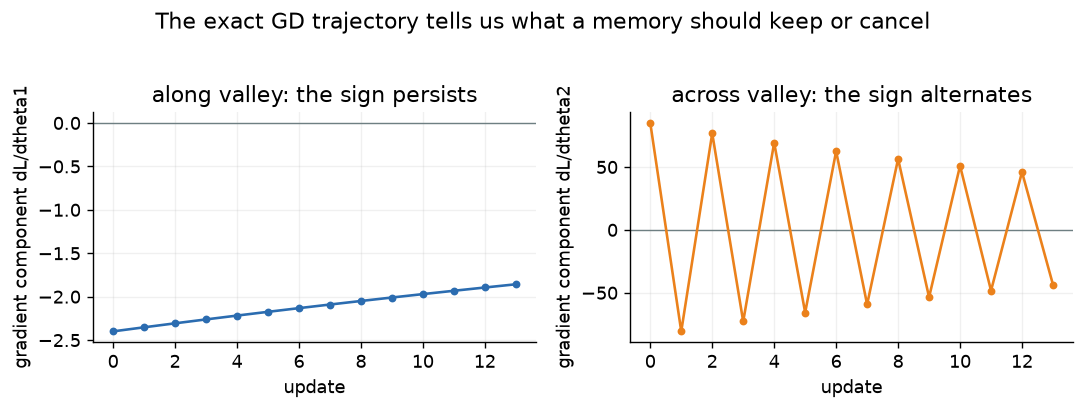

In [10]:
clue_path = gd_path(.0195, 14)
clue_gradients = np.array([grad_theta(theta) for theta in clue_path[:-1]])
updates = np.arange(len(clue_gradients))

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.15), sharex=True)
axes[0].axhline(0, color=MUTED, lw=.8)
axes[0].plot(updates, clue_gradients[:, 0], 'o-', color=BLUE, ms=3.5)
axes[0].set(
    title='along valley: the sign persists', xlabel='update',
    ylabel='gradient component dL/dtheta1',
)
axes[1].axhline(0, color=MUTED, lw=.8)
axes[1].plot(updates, clue_gradients[:, 1], 'o-', color=ORANGE, ms=3.5)
axes[1].set(
    title='across valley: the sign alternates', xlabel='update',
    ylabel='gradient component dL/dtheta2',
)
fig.suptitle('The exact GD trajectory tells us what a memory should keep or cancel', y=1.03)
plt.tight_layout()
plt.show()

assert np.all(clue_gradients[:, 0] < 0)
assert np.all(np.signbit(clue_gradients[1:, 1]) != np.signbit(clue_gradients[:-1, 1]))

### Momentum update 1: there is no history yet

Here $\boldsymbol m_t$ is the optimizer's normalized running memory of earlier gradients. Before any gradient has been observed, there is no history and no preferred direction, so we initialize $\boldsymbol m_0=\boldsymbol0$. This is an initial condition—not a measured gradient and not a learned parameter.

Use $\eta=.0195$ for both algorithms and $\beta=.25$ for momentum. At the actual start $\boldsymbol\theta_0=(-1.4,.35)$, perform one complete **measure → remember → move** cycle:

$$\underbrace{\boldsymbol g_0=(-2.4,85)}_{\text{measure}},$$

$$\underbrace{\boldsymbol m_1=.25\boldsymbol m_0+.75\boldsymbol g_0=.75\boldsymbol g_0=(-1.8,63.75)}_{\text{remember}},$$

$$\underbrace{\boldsymbol\theta_1^{\rm mom}=\boldsymbol\theta_0-.0195\boldsymbol m_1=(-1.3649,-.893125)}_{\text{move}}.$$

Plain GD uses the same $\eta$ but the raw gradient, so $\boldsymbol\theta_1^{\rm GD}=(-1.3532,-1.3075)$. Momentum's first move is smaller because $\boldsymbol m_0=\boldsymbol0$ and the first EWMA has only $.75$ total data weight.

### Momentum update 2: remeasure, then blend

At the momentum point $\boldsymbol\theta_1^{\rm mom}$, keep $\boldsymbol m_1=(-1.8,63.75)$ and recompute $\boldsymbol g_1=(-2.3649,-39.3125)$. The $\theta_1$ components have the same sign and reinforce; the $\theta_2$ components have opposite signs and mostly cancel. The code uses side-by-side pure-Python `gd_step` and `momentum_step` functions, then prints both complete momentum updates.

In [11]:
def gd_step(theta, grad, eta):
    next_theta = [
        x - eta * g
        for x, g in zip(theta, grad)
    ]
    return next_theta


def momentum_step(theta, grad, memory, eta, beta):
    next_memory = [
        beta * m + (1 - beta) * g
        for m, g in zip(memory, grad)
    ]
    next_theta = [
        x - eta * m
        for x, m in zip(theta, next_memory)
    ]
    return next_theta, next_memory


eta_shared = .0195
beta_m = .25
eta_m = eta_shared

# Update 1: initialize the one extra state once.
m0 = [0.0] * len(theta0)
g0 = grad_theta(theta0)
theta1, m1 = momentum_step(theta0, g0, m0, eta_m, beta_m)
theta1, m1 = np.asarray(theta1), np.asarray(m1)
plain_theta1 = np.asarray(gd_step(theta0, g0, eta_shared))

print('UPDATE 1 · same eta, different update rule')
print('start theta0   =', theta0)
print('initial m0     =', m0, '  # no gradient history yet')
print('measure g0     =', g0)
print('remember m1    =', m1)
print('momentum theta1=', theta1)
print('plain-GD theta1=', plain_theta1)

# Update 2: remeasure at the momentum point, then blend old and new directions.
g1 = grad_theta(theta1)
old_part = beta_m * m1
new_part = (1 - beta_m) * g1
theta2, m2 = momentum_step(theta1, g1, m1, eta_m, beta_m)
theta2, m2 = np.asarray(theta2), np.asarray(m2)

print('\nUPDATE 2 · remeasure, blend, move')
print('measure g1     =', g1)
print(f'theta1 component: {old_part[0]: .6f} + {new_part[0]: .6f} = {m2[0]: .6f}')
print(f'theta2 component: {old_part[1]: .6f} + {new_part[1]: .6f} = {m2[1]: .6f}')
print('remember m2    =', m2)
print('move theta2    =', theta2)

assert np.allclose(g0, [-2.4, 85.])
assert np.allclose(m1, [-1.8, 63.75])
assert np.allclose(theta1, [-1.3649, -.893125])
assert np.allclose(plain_theta1, [-1.3532, -1.3075])
assert not np.allclose(plain_theta1, theta1)
assert np.allclose(g1, [-2.3649, -39.3125])
assert np.allclose(m2, [-2.223675, -13.546875])
assert np.allclose(theta2, [-1.3215383375, -.6289609375])

UPDATE 1 · same eta, different update rule
start theta0   = [-1.4   0.35]
initial m0     = [0.0, 0.0]   # no gradient history yet
measure g0     = [-2.4 85. ]
remember m1    = [-1.8  63.75]
momentum theta1= [-1.3649   -0.893125]
plain-GD theta1= [-1.3532 -1.3075]

UPDATE 2 · remeasure, blend, move
measure g1     = [ -2.3649 -39.3125]
theta1 component: -0.450000 + -1.773675 = -2.223675
theta2 component:  15.937500 + -29.484375 = -13.546875
remember m2    = [ -2.223675 -13.546875]
move theta2    = [-1.3215383 -0.6289609]


### First six updates in tables

Both methods start from the same $\boldsymbol\theta_0=(-1.4,.35)$, use the same exact full-batch gradient, and use the same $\eta=.0195$. Update $k$ measures the gradient at $\boldsymbol\theta_{k-1}$ and produces $\boldsymbol\theta_k$.

For plain GD,

$$\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-.0195\boldsymbol g_t.$$

For normalized-EWMA momentum,

$$\boldsymbol m_{t+1}=.25\boldsymbol m_t+.75\boldsymbol g_t,\qquad
\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-.0195\boldsymbol m_{t+1},\qquad
\boldsymbol m_0=\boldsymbol0.$$

The first momentum memory is only $.75\boldsymbol g_0$, so the first momentum step is smaller than the first GD step. The tables keep $\theta_1$ and $\theta_2$ in separate rows so every multiplication can be checked directly. The loss is reported after both coordinates have moved.

In [12]:
from IPython.display import Markdown, display

plain_first7 = gd_path(eta_shared, 6)
plain_first_gradients = np.array([
    grad_theta(theta) for theta in plain_first7[:-1]
])

momentum_first7 = [theta0.copy()]
momentum_first_gradients = []
momentum_first_memories = []
theta = theta0.copy()
memory = np.zeros_like(theta0)
for _ in range(6):
    gradient = grad_theta(theta)
    memory = beta_m * memory + (1 - beta_m) * gradient
    theta = theta - eta_m * memory
    momentum_first_gradients.append(gradient.copy())
    momentum_first_memories.append(memory.copy())
    momentum_first7.append(theta.copy())

momentum_first7 = np.asarray(momentum_first7)
momentum_first_gradients = np.asarray(momentum_first_gradients)
momentum_first_memories = np.asarray(momentum_first_memories)
momentum_previous_memories = np.vstack([
    np.zeros(2), momentum_first_memories[:-1]
])


def number(value, places=4):
    if abs(value) < .5 * 10 ** (-places):
        value = 0.0
    return f'{value:.{places}f}'


plain_rows = []
for update, (before, gradient, after) in enumerate(zip(
    plain_first7[:-1], plain_first_gradients, plain_first7[1:]
), start=1):
    loss_after = loss_theta(after)
    for coordinate in range(2):
        loss_cell = f'`{loss_after:.3f}`' if coordinate == 1 else ''
        plain_rows.append(
            f'| {update} | theta{coordinate + 1} | `{number(before[coordinate])}` | '
            f'`{number(gradient[coordinate])}` | '
            f'`{number(before[coordinate])} - .0195({number(gradient[coordinate])}) '
            f'= {number(after[coordinate])}` | {loss_cell} |'
        )

plain_table = '\n'.join([
    '#### Plain gradient descent · eta = .0195',
    '',
    '| update | coordinate | current value | gradient | parameter calculation | loss after update |',
    '|---:|:---:|---:|---:|:---|---:|',
    *plain_rows,
])
display(Markdown(plain_table))

momentum_rows = []
for update, (before, gradient, previous_memory, memory, after) in enumerate(zip(
    momentum_first7[:-1], momentum_first_gradients,
    momentum_previous_memories, momentum_first_memories, momentum_first7[1:]
), start=1):
    loss_after = loss_theta(after)
    for coordinate in range(2):
        loss_cell = f'`{loss_after:.3f}`' if coordinate == 1 else ''
        momentum_rows.append(
            f'| {update} | theta{coordinate + 1} | `{number(gradient[coordinate])}` | '
            f'`.25({number(previous_memory[coordinate])}) + '
            f'.75({number(gradient[coordinate])}) = {number(memory[coordinate])}` | '
            f'`{number(before[coordinate])} - .0195({number(memory[coordinate])}) '
            f'= {number(after[coordinate])}` | {loss_cell} |'
        )

momentum_table = '\n'.join([
    '#### Normalized-EWMA momentum · beta = .25, eta = .0195',
    '',
    '| update | coordinate | gradient | memory calculation | parameter calculation | loss after update |',
    '|---:|:---:|---:|:---|:---|---:|',
    *momentum_rows,
])
display(Markdown(momentum_table))

assert np.allclose(plain_first7, [
    [-1.4, .35], [-1.3532, -1.3075],
    [-1.3073126, .267125], [-1.2623200043, -1.22876875],
    [-1.21820476421615, .1923303125],
    [-1.174949771313935, -1.157713796875],
    [-1.132538250773313, .12482810703125],
])
assert np.allclose(momentum_first7, [
    [-1.4, .35], [-1.3649, -.893125],
    [-1.3215383375, -.6289609375],
    [-1.276745423689063, -.37431455078125],
    [-1.232249793414876, -.494467923583984],
    [-1.188479232617636, -.532596928543091],
    [-1.145530083641294, -.494456171788597],
])
assert np.allclose(momentum_first_memories[0], [-1.8, 63.75])
assert np.allclose(momentum_first_memories[1], [-2.223675, -13.546875])
assert np.all(np.diff([loss_theta(theta) for theta in plain_first7]) < 0)
assert np.all(np.diff([loss_theta(theta) for theta in momentum_first7]) < 0)

#### Plain gradient descent · eta = .0195

| update | coordinate | current value | gradient | parameter calculation | loss after update |
|---:|:---:|---:|---:|:---|---:|
| 1 | theta1 | `-1.4000` | `-2.4000` | `-1.4000 - .0195(-2.4000) = -1.3532` |  |
| 1 | theta2 | `0.3500` | `85.0000` | `0.3500 - .0195(85.0000) = -1.3075` | `35.372` |
| 2 | theta1 | `-1.3532` | `-2.3532` | `-1.3532 - .0195(-2.3532) = -1.3073` |  |
| 2 | theta2 | `-1.3075` | `-80.7500` | `-1.3075 - .0195(-80.7500) = 0.2671` | `32.086` |
| 3 | theta1 | `-1.3073` | `-2.3073` | `-1.3073 - .0195(-2.3073) = -1.2623` |  |
| 3 | theta2 | `0.2671` | `76.7125` | `0.2671 - .0195(76.7125) = -1.2288` | `29.114` |
| 4 | theta1 | `-1.2623` | `-2.2623` | `-1.2623 - .0195(-2.2623) = -1.2182` |  |
| 4 | theta2 | `-1.2288` | `-72.8769` | `-1.2288 - .0195(-72.8769) = 0.1923` | `26.426` |
| 5 | theta1 | `-1.2182` | `-2.2182` | `-1.2182 - .0195(-2.2182) = -1.1749` |  |
| 5 | theta2 | `0.1923` | `69.2330` | `0.1923 - .0195(69.2330) = -1.1577` | `23.995` |
| 6 | theta1 | `-1.1749` | `-2.1749` | `-1.1749 - .0195(-2.1749) = -1.1325` |  |
| 6 | theta2 | `-1.1577` | `-65.7714` | `-1.1577 - .0195(-65.7714) = 0.1248` | `21.794` |

#### Normalized-EWMA momentum · beta = .25, eta = .0195

| update | coordinate | gradient | memory calculation | parameter calculation | loss after update |
|---:|:---:|---:|:---|:---|---:|
| 1 | theta1 | `-2.4000` | `.25(0.0000) + .75(-2.4000) = -1.8000` | `-1.4000 - .0195(-1.8000) = -1.3649` |  |
| 1 | theta2 | `85.0000` | `.25(0.0000) + .75(85.0000) = 63.7500` | `0.3500 - .0195(63.7500) = -0.8931` | `10.524` |
| 2 | theta1 | `-2.3649` | `.25(-1.8000) + .75(-2.3649) = -2.2237` | `-1.3649 - .0195(-2.2237) = -1.3215` |  |
| 2 | theta2 | `-39.3125` | `.25(63.7500) + .75(-39.3125) = -13.5469` | `-0.8931 - .0195(-13.5469) = -0.6290` | `3.526` |
| 3 | theta1 | `-2.3215` | `.25(-2.2237) + .75(-2.3215) = -2.2971` | `-1.3215 - .0195(-2.2971) = -1.2767` |  |
| 3 | theta2 | `-12.8961` | `.25(-13.5469) + .75(-12.8961) = -13.0588` | `-0.6290 - .0195(-13.0588) = -0.3743` | `3.382` |
| 4 | theta1 | `-2.2767` | `.25(-2.2971) + .75(-2.2767) = -2.2818` | `-1.2767 - .0195(-2.2818) = -1.2322` |  |
| 4 | theta2 | `12.5685` | `.25(-13.0588) + .75(12.5685) = 6.1617` | `-0.3743 - .0195(6.1617) = -0.4945` | `2.493` |
| 5 | theta1 | `-2.2322` | `.25(-2.2818) + .75(-2.2322) = -2.2446` | `-1.2322 - .0195(-2.2446) = -1.1885` |  |
| 5 | theta2 | `0.5532` | `.25(6.1617) + .75(0.5532) = 1.9553` | `-0.4945 - .0195(1.9553) = -0.5326` | `2.448` |
| 6 | theta1 | `-2.1885` | `.25(-2.2446) + .75(-2.1885) = -2.2025` | `-1.1885 - .0195(-2.2025) = -1.1455` |  |
| 6 | theta2 | `-3.2597` | `.25(1.9553) + .75(-3.2597) = -1.9559` | `-0.5326 - .0195(-1.9559) = -0.4945` | `2.303` |

### The first seven points on the loss contours

Point **0** is the common start. Points **1** through **6** are the parameter values after each row-pair in the tables. Both methods use $\eta=.0195$, but their first moves differ because normalized momentum starts from $\boldsymbol m_0=\boldsymbol0$. Only points 0, 1, 3, and 6 are numbered to keep the paths readable.

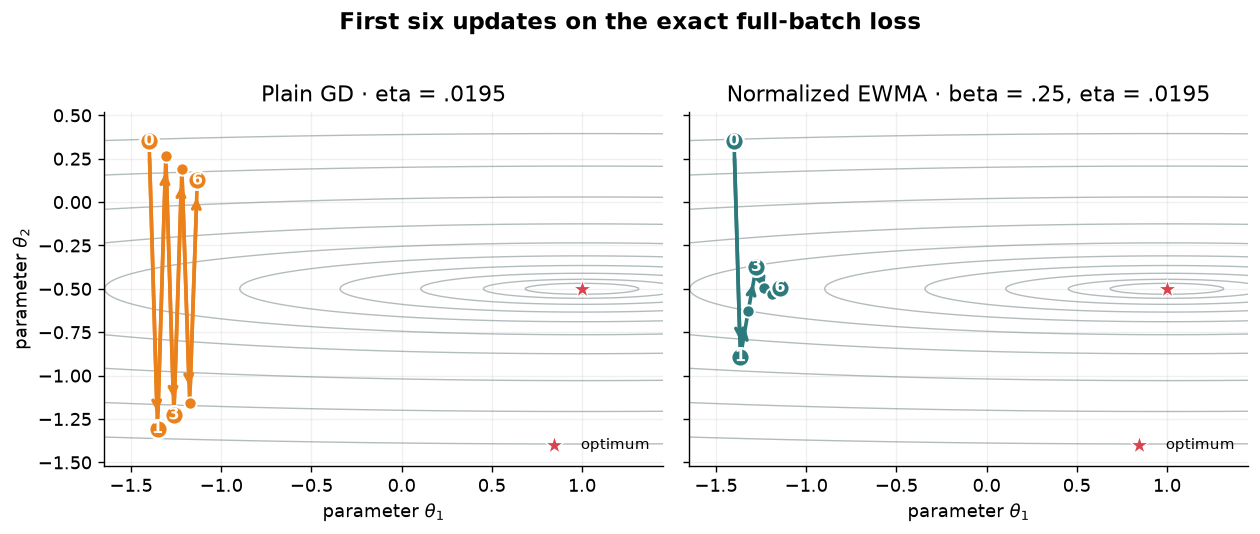

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.15), sharex=True, sharey=True)

for ax, path, title, color in [
    (axes[0], plain_first7, 'Plain GD · eta = .0195', ORANGE),
    (axes[1], momentum_first7, 'Normalized EWMA · beta = .25, eta = .0195', TEAL),
]:
    ax.contour(
        THETA1, THETA2, loss_grid, levels=contour_levels,
        colors=MUTED, alpha=.52, linewidths=.8,
    )
    ax.plot(path[:, 0], path[:, 1], color=color, lw=2.1, zorder=3)
    for start, end in zip(path[:-1], path[1:]):
        ax.annotate(
            '', xy=end, xytext=start,
            arrowprops=dict(
                arrowstyle='->', color=color, lw=2.1,
                shrinkA=10, shrinkB=10,
            ),
            zorder=4,
        )
    ax.scatter(
        path[:, 0], path[:, 1], s=50, color=color,
        edgecolor='white', linewidth=1.1, zorder=5,
    )
    labeled_steps = np.array([0, 1, 3, 6])
    ax.scatter(
        path[labeled_steps, 0], path[labeled_steps, 1], s=115, color=color,
        edgecolor='white', linewidth=1.4, zorder=5,
    )
    for step in labeled_steps:
        point = path[step]
        ax.text(
            point[0], point[1], str(step), ha='center', va='center',
            color='white', fontsize=9, fontweight='bold', zorder=6,
        )
    ax.scatter(
        *theta_star, marker='*', s=125, color=RED,
        edgecolor='white', linewidth=.7, label='optimum', zorder=5,
    )
    ax.set(
        xlim=(-1.65, 1.45), ylim=(-1.52, .52),
        xlabel=r'parameter $\theta_1$', title=title,
    )
    ax.legend(loc='lower right', fontsize=8.5)

axes[0].set_ylabel(r'parameter $\theta_2$')
fig.suptitle('First six updates on the exact full-batch loss',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

assert len(plain_first7) == len(momentum_first7) == 7
assert not np.allclose(plain_first7[1], momentum_first7[1])
assert not np.allclose(plain_first7[2], momentum_first7[2])

## 5. Test whether momentum actually helps

The two-step arithmetic explains the mechanism, but it is not yet evidence of better optimization. Compare both methods from the same $\boldsymbol\theta_0$ for **55 exact full-batch gradient evaluations**:

- plain GD: $\eta=.0195$;
- normalized-EWMA momentum: the same $\eta=.0195$, plus $\beta=.25$ and $\boldsymbol m_0=\boldsymbol0$.

There is no learning-rate rescaling in this conceptual comparison. The only change is the update rule. Because $\boldsymbol m_1=.75\boldsymbol g_0$, momentum's first move is smaller; later moves blend history.

For plain GD, the distances from the optimum update as

$$\theta_{t+1,1}-1=.9805(\theta_{t,1}-1),$$

$$\theta_{t+1,2}+0.5=-.95(\theta_{t,2}+0.5).$$

Both squared terms therefore shrink every time, although the steep coordinate zigzags slowly. With the displayed $\beta$, momentum also lowers the full loss at every update while damping that across-valley motion. We compare final loss and travel below; this remains one controlled mechanism example, not a universal optimizer ranking.

55 exact full-batch gradients from the same starting point and eta=.0195
method       final loss   |final theta1 - theta1*|   raw crossings   material crossings   across-valley travel
plain GD    0.458144213                  0.812511              55                   55              31.176297
momentum    0.329774879                  0.812127              30                   12               1.975095

Plain GD loss decreases on every update: True
Momentum loss also decreases on every update: True


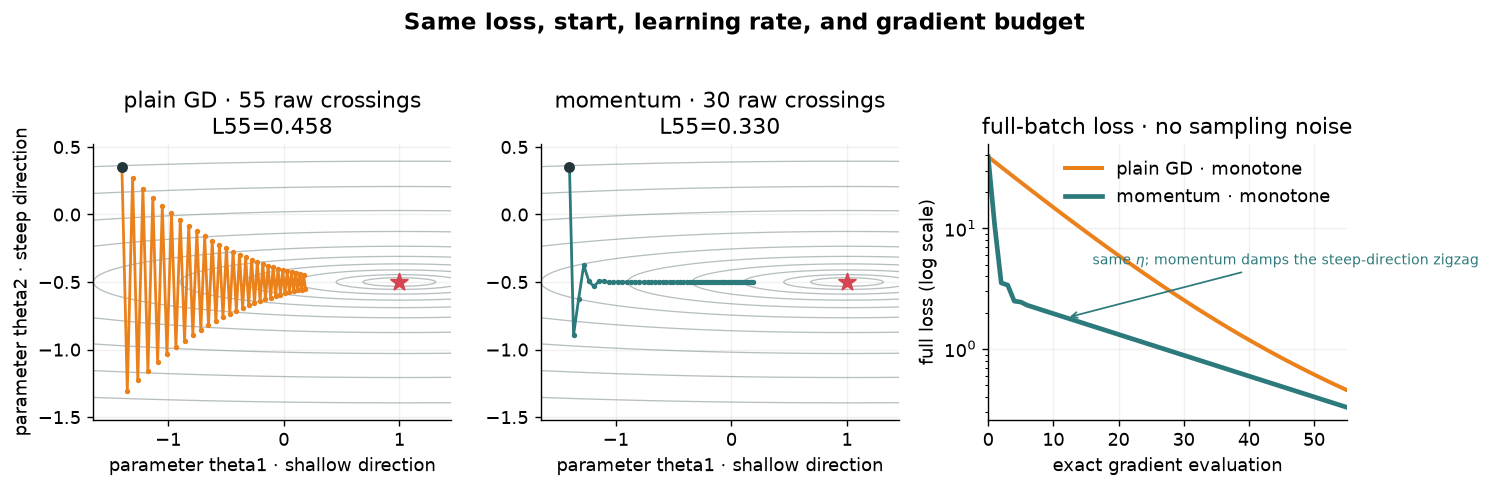

In [14]:
def momentum_trace(eta, beta, steps):
    theta = theta0.copy()
    memory = np.zeros(2)
    path = [theta.copy()]
    gradients = []
    memories = []
    for _ in range(steps):
        gradient = grad_theta(theta)
        memory = beta * memory + (1 - beta) * gradient
        theta = theta - eta * memory
        gradients.append(gradient.copy())
        memories.append(memory.copy())
        path.append(theta.copy())
    return np.asarray(path), np.asarray(gradients), np.asarray(memories)


steps = 55
eta_shared = .0195
beta_m = .25
plain_path = gd_path(eta_shared, steps)
momentum_path, momentum_gradients, momentum_memories = momentum_trace(
    eta_shared, beta_m, steps
)
plain_loss = np.array([loss_theta(theta) for theta in plain_path])
momentum_loss = np.array([loss_theta(theta) for theta in momentum_path])


def crossings(path):
    steep_error = path[:, 1] - theta_star[1]
    return int(np.count_nonzero(
        np.signbit(steep_error[1:]) != np.signbit(steep_error[:-1])
    ))


def material_crossings(path, tolerance=1e-6):
    steep_error = path[:, 1] - theta_star[1]
    changed_sign = np.signbit(steep_error[1:]) != np.signbit(steep_error[:-1])
    adjacent_scale = np.maximum(np.abs(steep_error[1:]), np.abs(steep_error[:-1]))
    return int(np.count_nonzero(changed_sign & (adjacent_scale > tolerance)))


def transverse_travel(path):
    return float(np.abs(np.diff(path[:, 1])).sum())


plain_crossings = crossings(plain_path)
momentum_crossings = crossings(momentum_path)
plain_material_crossings = material_crossings(plain_path)
momentum_material_crossings = material_crossings(momentum_path)
plain_transverse = transverse_travel(plain_path)
momentum_transverse = transverse_travel(momentum_path)

print('55 exact full-batch gradients from the same starting point and eta=.0195')
print('method       final loss   |final theta1 - theta1*|   raw crossings   material crossings   across-valley travel')
print(f'plain GD   {plain_loss[-1]:12.9f}   {abs(plain_path[-1,0]-theta_star[0]):23.6f}'
      f'   {plain_crossings:13d}   {plain_material_crossings:18d}   {plain_transverse:20.6f}')
print(f'momentum   {momentum_loss[-1]:12.9f}   {abs(momentum_path[-1,0]-theta_star[0]):23.6f}'
      f'   {momentum_crossings:13d}   {momentum_material_crossings:18d}   {momentum_transverse:20.6f}')
print(f'\nPlain GD loss decreases on every update: {np.all(np.diff(plain_loss) < 0)}')
print(f'Momentum loss also decreases on every update: {np.all(np.diff(momentum_loss) < 0)}')

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.75))
for ax, path, title, color in [
    (axes[0], plain_path,
     f'plain GD · {plain_crossings} raw crossings\nL55={plain_loss[-1]:.3f}', ORANGE),
    (axes[1], momentum_path,
     f'momentum · {momentum_crossings} raw crossings\nL55={momentum_loss[-1]:.3f}', TEAL),
]:
    ax.contour(THETA1, THETA2, loss_grid, levels=contour_levels,
               colors=MUTED, alpha=.5, linewidths=.75)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, ms=2.1, lw=1.6)
    ax.scatter(*theta0, color=INK, s=28, zorder=5)
    ax.scatter(*theta_star, marker='*', color=RED, s=105, zorder=5)
    ax.set(
        xlim=(-1.65, 1.45), ylim=(-1.52, .52),
        xlabel='parameter theta1 · shallow direction', title=title,
    )
axes[0].set_ylabel('parameter theta2 · steep direction')
axes[1].set_ylabel('')

update = np.arange(steps + 1)
axes[2].semilogy(update, plain_loss, color=ORANGE, lw=2.3, label='plain GD · monotone')
axes[2].semilogy(update, momentum_loss, color=TEAL, lw=2.7, label='momentum · monotone')
axes[2].annotate(
    r'same $\eta$; momentum damps the steep-direction zigzag',
    xy=(12, momentum_loss[12]), xytext=(16, 5), color=TEAL, fontsize=8.2,
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1),
)
axes[2].set(
    xlim=(0, 55), xlabel='exact gradient evaluation',
    ylabel='full loss (log scale)', title='full-batch loss · no sampling noise',
)
axes[2].legend()
fig.suptitle('Same loss, start, learning rate, and gradient budget', y=1.03,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

assert np.allclose(momentum_memories[0], [-1.8, 63.75])
assert not np.allclose(plain_path[1], momentum_path[1])
assert np.isclose(plain_loss[-1], 0.4581442126753134)
assert np.isclose(momentum_loss[-1], 0.3297748786564119)
assert np.all(np.diff(plain_loss) < 0)
assert np.all(np.diff(momentum_loss) < 0)
assert plain_crossings == 55
assert momentum_crossings == 30
assert plain_material_crossings == 55
assert momentum_material_crossings == 12
assert np.isclose(plain_transverse, 31.176296898251714)
assert np.isclose(momentum_transverse, 1.9750947352599555)
assert momentum_loss[-1] < plain_loss[-1]

## 6. Map the teaching recurrence to PyTorch

Everything above used one conceptual $\eta=.0195$ and the normalized EWMA recurrence directly. PyTorch stores an unnormalized buffer $\widetilde{\boldsymbol m}$:

$$\widetilde{\boldsymbol m}_{t+1}=\beta\widetilde{\boldsymbol m}_t+\boldsymbol g_t,\qquad
\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta_{\rm PT}\widetilde{\boldsymbol m}_{t+1}.$$

Its buffer is larger than our normalized memory by $1/(1-\beta)$:

$$\boldsymbol m=(1-\beta)\widetilde{\boldsymbol m}.$$

Therefore PyTorch needs `lr=(1-beta)*eta=(1-.25)*.0195=.014625` to reproduce the normalized recurrence. This is only an implementation conversion—not a second conceptual learning rate. The next cell checks every parameter point and scaled buffer.

In [15]:
eta = .0195
beta = .25
steps = 55
numpy_path, _, numpy_memories = momentum_trace(eta, beta, steps)

Xt = torch.tensor(X, dtype=torch.float64)
yt = torch.tensor(y, dtype=torch.float64)
theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
optimizer = torch.optim.SGD(
    [theta_param], lr=(1 - beta) * eta, momentum=beta
)

torch_path = [theta_param.detach().numpy().copy()]
torch_buffers = []
for _ in range(steps):
    optimizer.zero_grad(set_to_none=True)
    objective = 0.5 * ((Xt @ theta_param - yt) ** 2).mean()
    objective.backward()
    optimizer.step()
    torch_path.append(theta_param.detach().numpy().copy())
    torch_buffers.append(
        optimizer.state[theta_param]['momentum_buffer'].detach().numpy().copy()
    )

torch_path = np.asarray(torch_path)
torch_buffers = np.asarray(torch_buffers)
max_path_error = np.max(np.abs(torch_path - numpy_path))
max_state_error = np.max(np.abs((1 - beta) * torch_buffers - numpy_memories))

print('normalized conceptual eta:', eta)
print('PyTorch lr after buffer conversion:', optimizer.param_groups[0]['lr'])
print('first momentum_buffer:', torch_buffers[0])
print('first normalized memory:', numpy_memories[0])
print('maximum path difference:', max_path_error)
print('maximum scaled-buffer difference:', max_state_error)

assert np.isclose(optimizer.param_groups[0]['lr'], .014625)
assert np.allclose(torch_path, numpy_path, atol=1e-12)
assert np.allclose((1 - beta) * torch_buffers, numpy_memories, atol=1e-12)

normalized conceptual eta: 0.0195
PyTorch lr after buffer conversion: 0.014624999999999999
first momentum_buffer: [-2.4 85. ]
first normalized memory: [-1.8  63.75]
maximum path difference: 2.220446049250313e-16
maximum scaled-buffer difference: 1.7763568394002505e-14


### Minimal PyTorch use

```python
# PyTorch's buffer convention needs lr=(1-.25)*.0195=.014625.
optimizer = torch.optim.SGD(model.parameters(), lr=0.014625, momentum=0.25)

for xb, yb in loader:
    optimizer.zero_grad(set_to_none=True)
    loss = loss_fn(model(xb), yb)
    loss.backward()
    optimizer.step()
```

The normalized recurrence explains the idea in the same units as signal smoothing. PyTorch handles the equivalent buffer scaling, parameter groups, devices, dtypes, and state storage.

## Takeaways

1. EWMA's $\beta$ is a memory dial: `.5` reacts, `.9` balances, and `.98` is smooth but slow to turn on the same noisy signal.
2. The four raw-feature regression rows produce real $100{:}1$ curvature, so an exact gradient can still zigzag under one global learning rate.
3. Four separate, standardized rows show the complementary point: correlation $.8$ still gives condition number $9$. With the same $\eta=1$, both GD and normalized-EWMA momentum decrease smoothly in the computed comparison; momentum starts smaller because $\boldsymbol m_0=\boldsymbol0$ and remains lower here.
4. On the controlled 55-gradient raw-feature comparison, both methods use $\eta=.0195$ and both losses decrease at every update. Momentum finishes at `.329775` versus `.458144` for GD and reduces total across-valley travel from `31.176` to `1.975`.
5. Signal smoothing and optimizer momentum use the same normalized EWMA recurrence. A signal may warm-start at its first reading; optimizer momentum starts from $\boldsymbol m_0=\boldsymbol0$ because it has no gradient history.
6. PyTorch's unnormalized buffer is an implementation convention. For $\beta=.25$ and normalized $\eta=.0195$, `lr=(1-beta)*eta=.014625` reproduces the same parameter path exactly.